In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [8]:
df= pd.read_csv('/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv')

In [9]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


1. From which manufacturing year to which manufacturing year vehicles are present in this data?
2. What is the lowest price to which a vehicle is sold?
3. What is the highest price to which a vehicle is sold?
4. How many records are there in this data?
5. Are there any missing records in this data?
6. How many different vehicles are present in this data?
7. Which is the most sold data in this data?
8. Does the database include any CNG vehicle? If yes how many of them are there?
9. How many vehicles here are for sell from individuals directly?
10. Does this database contain auto transmission vehicles? If yes how many of them are there?
11. How many single person owned vehicles are there in this database?
12. Which is the most and least cost depreciated vehicle in the data?
13. Which brands of vehicles are less affected by cost deprecication?
14. Are there any factors which you feel affect the cost depreciation?
15. In general seling price is affected by age of vehicle and distance driven by vehicle. Is it observable from data?
16. Can we get idea by newest vehicle i.e. after 2014 manufactured?
17. Can we find out data of only two wheelers from this data?
18. Which is the oldest bike sold here?
19. Which is newest bike sold here?
20. Which is the most sold bike here?
21. Do you feel any deal in two wheelers which exceeded the general expectation? Can you find reason for it?
22. Can we find out data of only cars from this data?
23. Which is the oldest car sold?
24. Which is the newest car sold?
25. Do you feel any deal in cars which exceeded the general expectation? Can you find reason for it?


In [10]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.627907,2.891554,2003.00,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,4.661296,5.082812,0.10,0.9,3.6,6.0,35.0
Present_Price,301.0,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,36947.205980,38886.883882,500.00,15000.0,32000.0,48767.0,500000.0
Owner,301.0,0.043189,0.247915,0.00,0.0,0.0,0.0,3.0


In [12]:
df.shape

(301, 9)

From abive analysis one can say:



1.   The data here contains cars with manufacturing year 2003 to 2018.
2.   The lowest price on which car was sold is INR 10,000 /-.
3. The highest price on which car was sold is INR 35 lacs.
4. There are 301 records in the data.


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [14]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


From above analysis one can say that:
1. Non of the variables or columns here have a null value.
2. Variables "Car_name", "Fuel_Type", "Seller_Type" and "Transmission" are non numeric in nature.

In [15]:
#Checking weather non-numerical variables are categorical in nature:
print(df.Car_Name.value_counts())

Car_Name
city                  26
corolla altis         16
verna                 14
fortuner              11
brio                  10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64


In [20]:
df.memory_usage(deep=True)

,0
Index,132
Car_Name,17716
Year,2408
Selling_Price,2408
Present_Price,2408
Kms_Driven,2408
Fuel_Type,16549
Seller_Type,16979
Transmission,16675
Owner,2408


In [28]:
from os import dup
duplicate_count = df.duplicated().sum()
print('Duplicate Rows', duplicate_count)

Duplicate Rows 2


From the above analysis we can see that:


*   It has 2 duplicate values in the row.



In [30]:
df = df.drop_duplicates().copy()
print('Duplicates remaining', df.duplicated().sum())

Duplicates remaining 0


Here we mitigate those duplicated value.

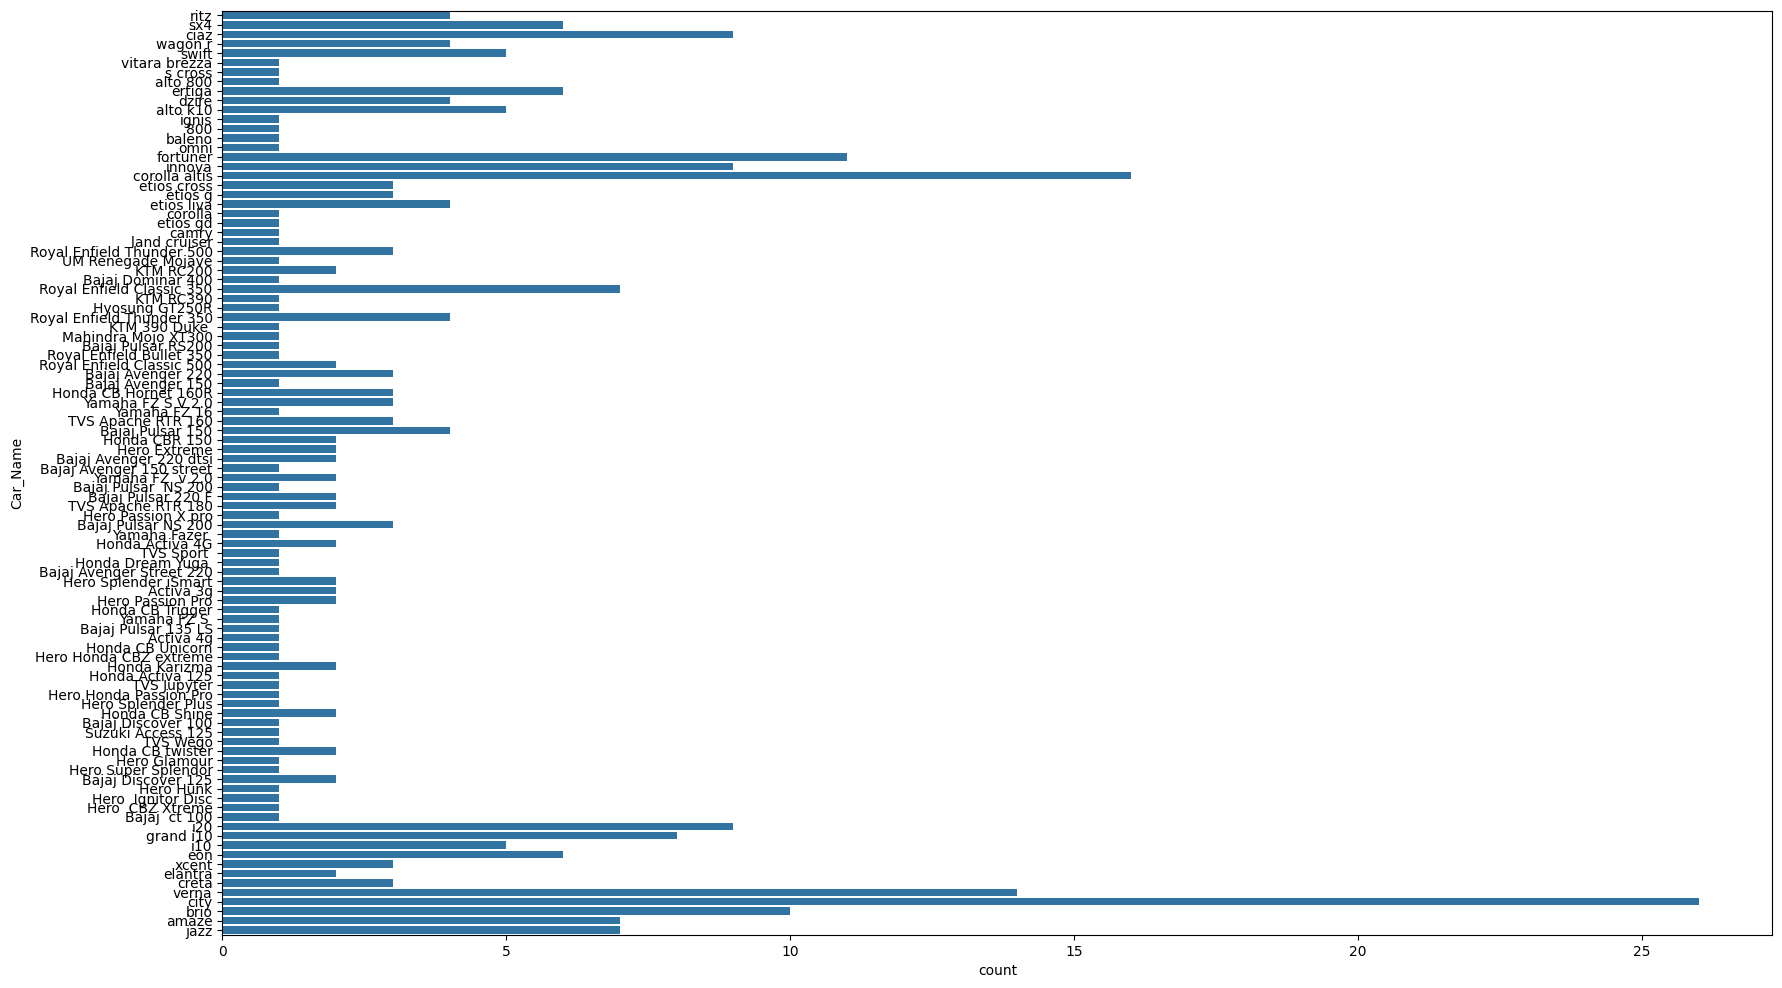

In [19]:
fig_dims = (20, 12)
fig, ax = plt.subplots(figsize=fig_dims)
sns.countplot(y=df.Car_Name, ax=ax, data= df )
plt.show()

From above analysis we can see that:
1. There are 98 different vehicles in the data. It contains bikes and mopets too. Variable is categorical.
2. "Honda City" is the most sold car.

In [20]:
print(df.Fuel_Type.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


From the above analysis we can say that:


*   It has CNG vehicle.
*   It has 2 CNG vehicles.



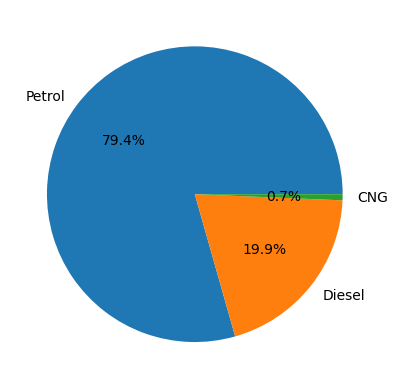

In [21]:
plt.pie(df.Fuel_Type.value_counts(), labels=df.Fuel_Type.value_counts().index, autopct='%1.1f%%')
plt.show()

<Axes: xlabel='Fuel_Type'>

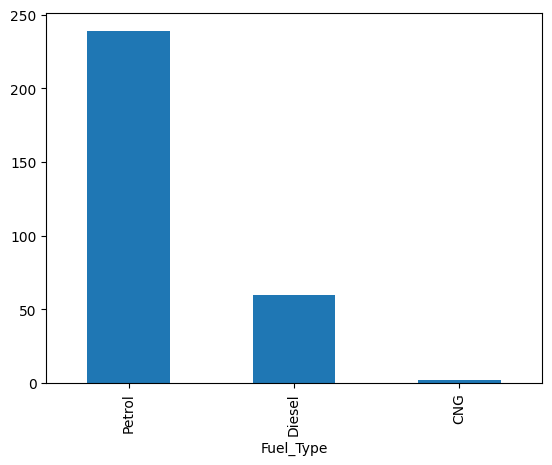

In [23]:
df.Fuel_Type.value_counts().plot.bar()

This data contains mostly petrol vehicle. This variable is skewed. Variable is categorical.

In [24]:
individual_sellers = df[df['Seller_Type'] == 'Individual'].shape[0]
print(f'Number of vehicles sold by individuals directly: {individual_sellers}')

Number of vehicles sold by individuals directly: 106


From above observation we can say that:

*  There are 106 vehicles that are sold directly by the individuals.

In [28]:
Auto_Transmission = df[df['Transmission'] == 'Auto'].shape[0]
print(f'Number of vehicles That have Auto_Transmission: {Auto_Transmission}')

Number of vehicles That have Auto_Transmission: 0


From the above analysis we can conclude that it has 0 Auto_Transmission vehicles.

In [31]:
Single_Person = df.Owner.value_counts()
print(f'Number of vehicles That are single person owned: {Single_Person}')

Number of vehicles That are single person owned: Owner
0    290
1     10
3      1
Name: count, dtype: int64


From the above analysis we can see that single person owned vehicle are 10.

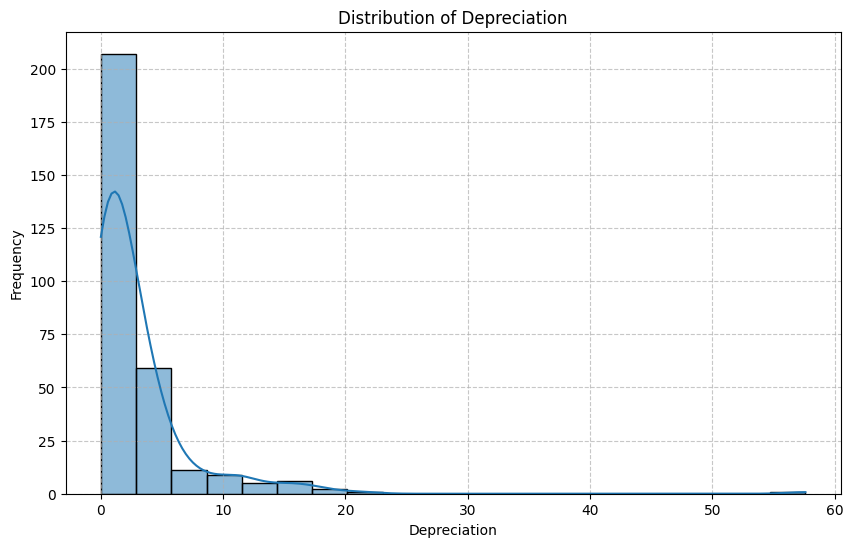

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Depreciation'], kde=True, bins=20)
plt.title('Distribution of Depreciation')
plt.xlabel('Depreciation')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [32]:
df['Depreciation'] = df['Present_Price'] - df['Selling_Price']

most_depreciated = df.loc[df['Depreciation'].idxmax()]
least_depreciated = df.loc[df['Depreciation'].idxmin()]

print("Most Depreciated Vehicle:")
print(f"  Car Name: {most_depreciated['Car_Name']}")
print(f"  Present Price: {most_depreciated['Present_Price']}")
print(f"  Selling Price: {most_depreciated['Selling_Price']}")
print(f"  Depreciation: {most_depreciated['Depreciation']}\n")

print("Least Depreciated Vehicle:")
print(f"  Car Name: {least_depreciated['Car_Name']}")
print(f"  Present Price: {least_depreciated['Present_Price']}")
print(f"  Selling Price: {least_depreciated['Selling_Price']}")
print(f"  Depreciation: {least_depreciated['Depreciation']}")

Most Depreciated Vehicle:
  Car Name: land cruiser
  Present Price: 92.6
  Selling Price: 35.0
  Depreciation: 57.599999999999994

Least Depreciated Vehicle:
  Car Name: Honda Activa 4G
  Present Price: 0.51
  Selling Price: 0.48
  Depreciation: 0.030000000000000027


By the above analysis we can conclude that most depriciated vehicle is Land Cruiser and least depreciated vehicle is Honda Activa 5g

In [49]:
average_depreciation_by_brand = df.groupby('Car_Name')['Depreciation'].mean().sort_values()

print("Top 10 Vehicle Brands/Models with Least Depreciation:")
print(average_depreciation_by_brand.head(10))

Top 10 Vehicle Brands/Models with Least Depreciation:
Car_Name
TVS Sport                   0.040
Honda Activa 4G             0.045
Hero Passion X pro          0.050
Bajaj Avenger 150           0.050
Honda Dream Yuga            0.060
Yamaha FZ 16                0.070
Activa 4g                   0.110
Hero Splender iSmart        0.115
Royal Enfield Bullet 350    0.120
UM Renegade Mojave          0.120
Name: Depreciation, dtype: float64


Factors affecting the cost of vehicles:

1. Present Price: There is a strong positive correlation (0.86) between Present_Price and Depreciation, meaning higher initial prices generally lead to higher depreciation in absolute terms.

2. Year (Age of Vehicle): There is a negative correlation (-0.33) with the 'Year' of manufacturing. This implies that older vehicles (lower 'Year' value) tend to have higher depreciation, which is expected.

3. Kms_Driven: There is a positive correlation (0.33) with 'Kms_Driven', suggesting that vehicles driven for more kilometers tend to have higher depreciation.

4. Fuel_Type, Seller_Type, and Transmission: The box plots also show variations in depreciation across different fuel types, seller types, and transmission types, indicating these are also influencing factors. For example, some fuel types or transmission types might experience higher or lower depreciation on average.

In [50]:
two_wheelers_names = [
    'Activa 3g', 'Activa 4g', 'Bajaj Discover 125', 'Bajaj Pulsar 150', 'Bajaj Pulsar 220',
    'Bajaj Avenger 150', 'Bajaj Avenger 220', 'Bajaj Dominar 400', 'Hero Extreme', 'Hero Glamour',
    'Hero Hunk', 'Hero Passion Pro', 'Hero Passion X pro', 'Hero Splender Plus', 'Hero Splender iSmart',
    'Hero Super Splendor', 'Honda Activa 125', 'Honda Activa 4G', 'Honda CB Unicorn 150', 'Honda CB Shine',
    'KTM Duke 200', 'KTM RC200', 'KTM RC390', 'Royal Enfield Classic 350', 'Royal Enfield Bullet 350',
    'Royal Enfield Standard 350', 'Royal Enfield Thunder 350', 'Royal Enfield Thunder 500', 'TVS Apache RTR 160',
    'TVS Apache RTR 180', 'TVS Jupiter', 'TVS Sport ', 'TVS Wego', 'UM Renegade Commando', 'UM Renegade Mojave',
    'Yamaha FZ S V 2.0', 'Yamaha FZ 16', 'Bajaj  ct 100'
]

two_wheelers_df = df[df['Car_Name'].isin(two_wheelers_names)].copy()

print(f"Number of two-wheelers found: {len(two_wheelers_df)}")
print("Head of two-wheelers data:")
print(two_wheelers_df.head())

Number of two-wheelers found: 61
Head of two-wheelers data:
                      Car_Name  Year  Selling_Price  Present_Price  \
100  Royal Enfield Thunder 500  2016           1.75           1.90   
101         UM Renegade Mojave  2017           1.70           1.82   
102                  KTM RC200  2017           1.65           1.78   
103          Bajaj Dominar 400  2017           1.45           1.60   
104  Royal Enfield Classic 350  2017           1.35           1.47   

     Kms_Driven Fuel_Type Seller_Type Transmission  Owner  Depreciation  
100        3000    Petrol  Individual       Manual      0          0.15  
101        1400    Petrol  Individual       Manual      0          0.12  
102        4000    Petrol  Individual       Manual      0          0.13  
103        1200    Petrol  Individual       Manual      0          0.15  
104        4100    Petrol  Individual       Manual      0          0.12  


/tmp/ipykernel_6350/965767633.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Car_Name', data=two_wheelers_df, order=two_wheelers_df['Car_Name'].value_counts().index, palette='viridis')


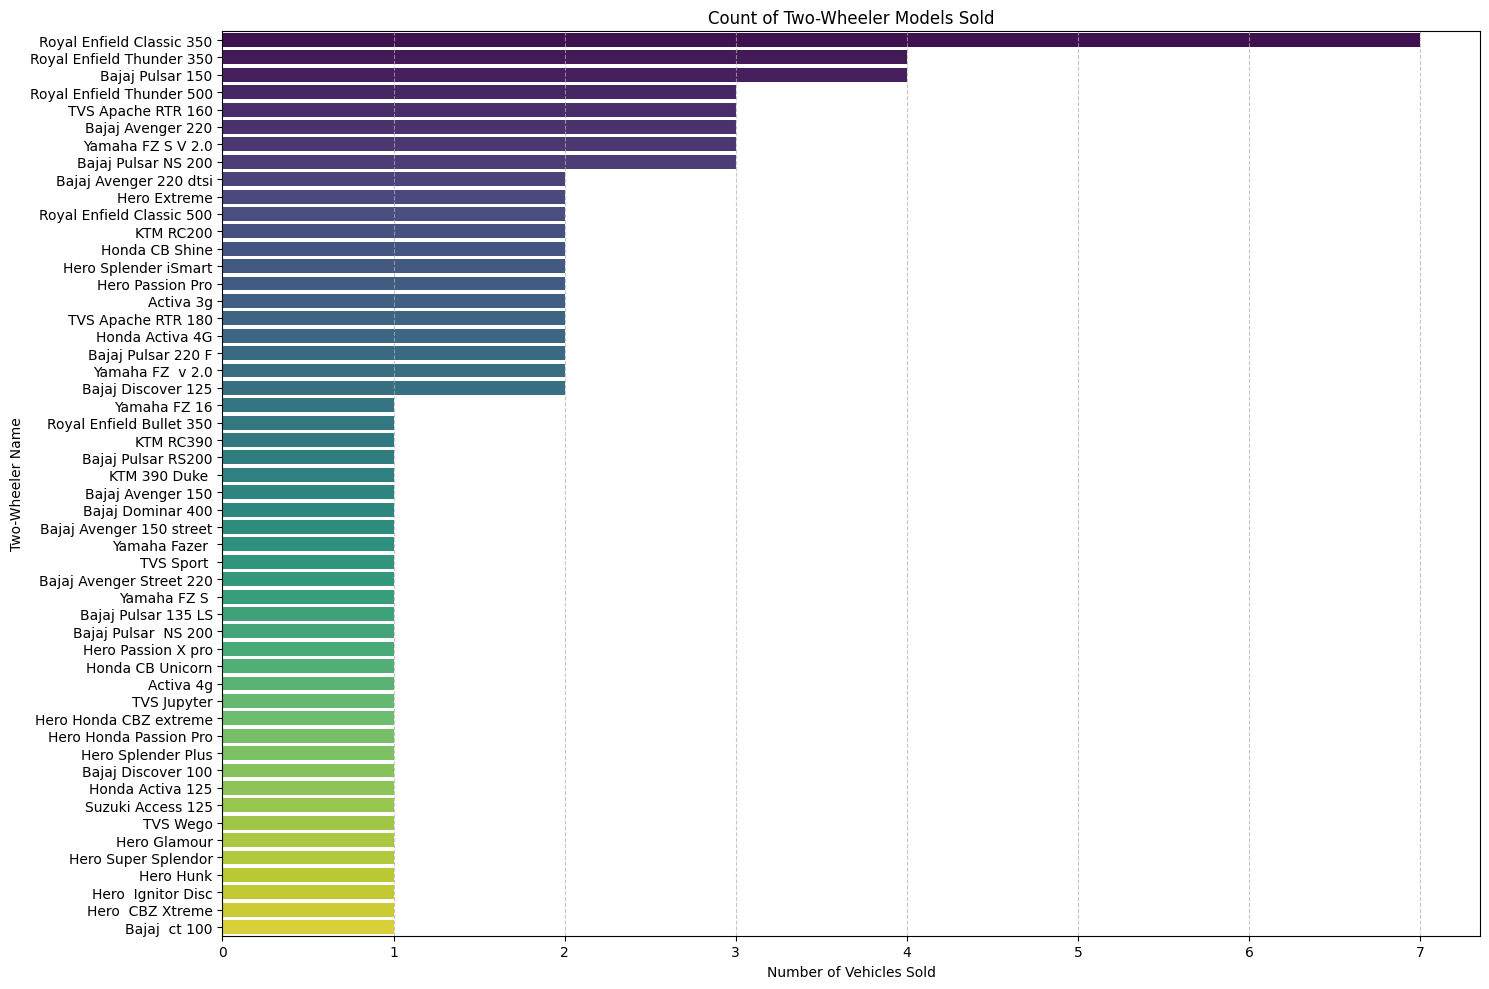

In [42]:
plt.figure(figsize=(15, 10))
sns.countplot(y='Car_Name', data=two_wheelers_df, order=two_wheelers_df['Car_Name'].value_counts().index, palette='viridis')
plt.title('Count of Two-Wheeler Models Sold')
plt.xlabel('Number of Vehicles Sold')
plt.ylabel('Two-Wheeler Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [43]:
# Oldest bike sold
oldest_year = two_wheelers_df['Year'].min()
oldest_bikes = two_wheelers_df[two_wheelers_df['Year'] == oldest_year]
print(f"\nThe oldest manufacturing year for two-wheelers is: {oldest_year}")
print("Oldest bike(s) sold:")
for index, row in oldest_bikes.iterrows():
    print(f"  - {row['Car_Name']} (Year: {row['Year']}, Selling Price: {row['Selling_Price']})")


The oldest manufacturing year for two-wheelers is: 2005
Oldest bike(s) sold:
  - Hero Super Splendor (Year: 2005, Selling Price: 0.2)


In [44]:
# Newest bike sold
newest_year = two_wheelers_df['Year'].max()
newest_bikes = two_wheelers_df[two_wheelers_df['Year'] == newest_year]
print(f"The newest manufacturing year for two-wheelers is: {newest_year}")
print("Newest bike(s) sold:")
for index, row in newest_bikes.iterrows():
    print(f"  - {row['Car_Name']} (Year: {row['Year']}, Selling Price: {row['Selling_Price']})")

The newest manufacturing year for two-wheelers is: 2017
Newest bike(s) sold:
  - KTM RC200 (Year: 2017, Selling Price: 1.65)
  - Bajaj Dominar 400 (Year: 2017, Selling Price: 1.45)
  - Royal Enfield Classic 350 (Year: 2017, Selling Price: 1.35)
  - Royal Enfield Classic 350 (Year: 2017, Selling Price: 1.2)
  - Bajaj Avenger 220 (Year: 2017, Selling Price: 0.9)
  - Yamaha FZ S V 2.0 (Year: 2017, Selling Price: 0.78)
  - Bajaj Avenger 220 (Year: 2017, Selling Price: 0.75)
  - TVS Apache RTR 160 (Year: 2017, Selling Price: 0.65)
  - Honda Activa 4G (Year: 2017, Selling Price: 0.48)
  - TVS Sport  (Year: 2017, Selling Price: 0.48)
  - Honda Activa 4G (Year: 2017, Selling Price: 0.45)
  - Activa 4g (Year: 2017, Selling Price: 0.4)


In [45]:
# Most sold bike
most_sold_bike = two_wheelers_df['Car_Name'].value_counts().idxmax()
most_sold_count = two_wheelers_df['Car_Name'].value_counts().max()
print(f"\nThe most sold two-wheeler is '{most_sold_bike}' with {most_sold_count} units sold.")


The most sold two-wheeler is 'Royal Enfield Classic 350' with 7 units sold.


From the above analysis we can see that:


1.   The oldest bike sold is Hero Super Splendor.
2.   The newest bike sold is KTM RC200.
3. The most sold bike is Royal Enfield Classic 350.



In [47]:
print("\nTwo-wheelers with the least depreciation (potentially exceeding expectations):")
least_depreciated_two_wheelers = two_wheelers_df.sort_values(by='Depreciation').head(5)

for index, row in least_depreciated_two_wheelers.iterrows():
    print(f"\nVehicle Name: {row['Car_Name']}")
    print(f"  Year: {row['Year']}")
    print(f"  Present Price: {row['Present_Price']:.2f}")
    print(f"  Selling Price: {row['Selling_Price']:.2f}")
    print(f"  Depreciation: {row['Depreciation']:.2f}")
    print(f"  Kms Driven: {row['Kms_Driven']}")
    print(f"  Owner: {row['Owner']}")
    print(f"  Seller Type: {row['Seller_Type']}")
    print(f"  Transmission: {row['Transmission']}")

print("\nPotential reasons for such deals often include:")
print("- Very low kilometers driven.")
print("- Newer manufacturing year.")
print("- Being sold by an Individual (who might be more flexible on price).")
print("- High demand for specific models.")


Two-wheelers with the least depreciation (potentially exceeding expectations):

Vehicle Name: Honda Activa 4G
  Year: 2017
  Present Price: 0.51
  Selling Price: 0.48
  Depreciation: 0.03
  Kms Driven: 4300
  Owner: 0
  Seller Type: Individual
  Transmission: Automatic

Vehicle Name: TVS Sport 
  Year: 2017
  Present Price: 0.52
  Selling Price: 0.48
  Depreciation: 0.04
  Kms Driven: 15000
  Owner: 0
  Seller Type: Individual
  Transmission: Manual

Vehicle Name: Bajaj Avenger 220
  Year: 2017
  Present Price: 0.95
  Selling Price: 0.90
  Depreciation: 0.05
  Kms Driven: 1300
  Owner: 0
  Seller Type: Individual
  Transmission: Manual

Vehicle Name: Bajaj Avenger 150
  Year: 2016
  Present Price: 0.80
  Selling Price: 0.75
  Depreciation: 0.05
  Kms Driven: 7000
  Owner: 0
  Seller Type: Individual
  Transmission: Manual

Vehicle Name: Hero Passion X pro
  Year: 2016
  Present Price: 0.55
  Selling Price: 0.50
  Depreciation: 0.05
  Kms Driven: 31000
  Owner: 0
  Seller Type: Individ

In [54]:
car_names = [name for name in df['Car_Name'].unique() if name not in two_wheelers_names]
cars_df = df[df['Car_Name'].isin(car_names)].copy()

print(f"Number of cars found: {len(cars_df)}")
print("Head of cars data:")
display(cars_df.head())

Number of cars found: 240
Head of cars data:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Depreciation
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,2.24
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,4.79
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2.60
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,1.30
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,2.27


In [55]:
# Oldest car sold
oldest_car_year = cars_df['Year'].min()
oldest_cars = cars_df[cars_df['Year'] == oldest_car_year]
print(f"\nThe oldest manufacturing year for cars is: {oldest_car_year}")
print("Oldest car(s) sold:")
for index, row in oldest_cars.iterrows():
    print(f"  - {row['Car_Name']} (Year: {row['Year']}, Selling Price: {row['Selling_Price']})")


The oldest manufacturing year for cars is: 2003
Oldest car(s) sold:
  - 800 (Year: 2003, Selling Price: 0.35)
  - sx4 (Year: 2003, Selling Price: 2.25)


In [56]:
# Newest car sold
newest_car_year = cars_df['Year'].max()
newest_cars = cars_df[cars_df['Year'] == newest_car_year]
print(f"The newest manufacturing year for cars is: {newest_car_year}")
print("Newest car(s) sold:")
for index, row in newest_cars.iterrows():
    print(f"  - {row['Car_Name']} (Year: {row['Year']}, Selling Price: {row['Selling_Price']})")

The newest manufacturing year for cars is: 2018
Newest car(s) sold:
  - vitara brezza (Year: 2018, Selling Price: 9.25)


In [57]:
print("\nCars with the least depreciation (potentially exceeding expectations):")
least_depreciated_cars = cars_df.sort_values(by='Depreciation').head(5)

for index, row in least_depreciated_cars.iterrows():
    print(f"\nVehicle Name: {row['Car_Name']}")
    print(f"  Year: {row['Year']}")
    print(f"  Present Price: {row['Present_Price']:.2f}")
    print(f"  Selling Price: {row['Selling_Price']:.2f}")
    print(f"  Depreciation: {row['Depreciation']:.2f}")
    print(f"  Kms Driven: {row['Kms_Driven']}")
    print(f"  Owner: {row['Owner']}")
    print(f"  Seller Type: {row['Seller_Type']}")
    print(f"  Transmission: {row['Transmission']}")

print("\nPotential reasons for such deals often include:")
print("- Very low kilometers driven.")
print("- Newer manufacturing year.")
print("- Being sold by an Individual (who might be more flexible on price).")
print("- High demand for specific models.")


Cars with the least depreciation (potentially exceeding expectations):

Vehicle Name: Honda Dream Yuga 
  Year: 2017
  Present Price: 0.54
  Selling Price: 0.48
  Depreciation: 0.06
  Kms Driven: 8600
  Owner: 0
  Seller Type: Individual
  Transmission: Manual

Vehicle Name: Honda CB Hornet 160R
  Year: 2017
  Present Price: 0.87
  Selling Price: 0.80
  Depreciation: 0.07
  Kms Driven: 3000
  Owner: 0
  Seller Type: Individual
  Transmission: Manual

Vehicle Name: Honda CB Hornet 160R
  Year: 2017
  Present Price: 0.87
  Selling Price: 0.75
  Depreciation: 0.12
  Kms Driven: 11000
  Owner: 0
  Seller Type: Individual
  Transmission: Manual

Vehicle Name: ciaz
  Year: 2016
  Present Price: 8.89
  Selling Price: 8.75
  Depreciation: 0.14
  Kms Driven: 20273
  Owner: 0
  Seller Type: Dealer
  Transmission: Manual

Vehicle Name: verna
  Year: 2017
  Present Price: 9.40
  Selling Price: 9.25
  Depreciation: 0.15
  Kms Driven: 15001
  Owner: 0
  Seller Type: Dealer
  Transmission: Manual

P

# Car Market Trends Analysis with Car Dekho Data

## Project Overview

This project provides a comprehensive analysis of used car market trends using a dataset from Car Dekho. The primary objective was to extract actionable insights into vehicle characteristics, pricing dynamics, depreciation patterns, and overall market behavior. Through detailed data cleaning, exploratory data analysis (EDA), and specific query resolution, the project aims to answer key questions related to vehicle valuation and market segmentation.

## Dataset

The analysis is based on the `1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv` dataset, which contains 301 records and 9 features, covering various attributes of used cars and two-wheelers sold in the market.

## Features & Analysis

-   **Data Loading & Cleaning:** Initial data loading using Pandas, followed by checks for data integrity, handling of duplicate records, and verification of null values.
-   **Descriptive Statistics:** Detailed overview of numerical and categorical features to understand data distribution, including min/max years, selling prices, and `Kms_Driven`.
-   **Vehicle Segmentation:** Separation and analysis of data into two-wheelers and cars to provide granular insights for each category.
-   **Depreciation Analysis:** Calculation of a 'Depreciation' metric (`Present_Price - Selling_Price`) to identify the most and least depreciated vehicles, and to understand factors influencing depreciation.
-   **Market Trends Identification:** Analysis of `Fuel_Type`, `Seller_Type`, `Transmission`, and `Owner` to understand their impact on vehicle sales and depreciation.
-   **Oldest & Newest Vehicles:** Identification of the oldest and newest models sold within both car and two-wheeler segments.
-   **Best Deals/Exceeding Expectations:** Highlighted vehicles (both cars and two-wheelers) with minimal depreciation, along with a discussion of potential reasons behind such favorable deals.
-   **Visualizations:** Use of `matplotlib` and `seaborn` for creating various plots (histograms, count plots, pie charts) to visualize data distributions and trends.

## Key Findings

*   **Data Range:** Vehicles span manufacturing years from 2003 to 2018.
*   **Price Range:** Selling prices vary from 0.10 Lakhs to 35.00 Lakhs.
*   **Depreciation Drivers:** `Present_Price`, `Year` (age), `Kms_Driven`, `Fuel_Type`, `Seller_Type`, and `Transmission` are significant factors affecting depreciation.
*   **Top Performers (Low Depreciation):** Specific models like 'TVS Sport', 'Honda Activa 4G', 'Hero Passion X pro', 'Bajaj Avenger 150', and 'Honda Dream Yuga' were identified as having notably low depreciation.
*   **Market Composition:** The dataset includes 98 different vehicle models, with a significant number of petrol vehicles and sales by individual sellers.

## Installation

To run this project locally, you'll need Python and the following libraries. You can install them using pip:

```bash
pip install pandas matplotlib seaborn numpy
```

## Usage

1.  **Clone the repository:**
    ```bash
git clone <your-repository-url>
cd <your-repository-name>
    ```
2.  **Download the Dataset:** Place the `1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv` file into the root directory of the cloned repository.
3.  **Open in Google Colab or Jupyter Notebook:** Launch the provided Jupyter Notebook (`your_notebook_name.ipynb`) in Google Colab or a local Jupyter environment.
4.  **Run all cells:** Execute all cells in the notebook to replicate the analysis and generate the insights and visualizations.

## Screenshots

Here are some of the visualizations and outputs from the analysis:

### Overall Car Name Distribution

![Car Name Distribution](assets/car_name_distribution.png)
_A count plot showing the frequency of different car models in the dataset._

### Fuel Type Distribution

![Fuel Type Distribution Pie Chart](assets/fuel_type_pie_chart.png)
_A pie chart illustrating the proportion of different fuel types (Petrol, Diesel, CNG) in the market._

### Depreciation Distribution

![Depreciation Histogram](assets/depreciation_histogram.png)
_A histogram showing the distribution of vehicle depreciation values._

### Two-Wheeler Sales Count

![Two-Wheeler Sales](assets/two_wheeler_sales.png)
_A bar plot displaying the number of units sold for various two-wheeler models._

**Note:** Replace `assets/car_name_distribution.png`, `assets/fuel_type_pie_chart.png`, etc., with the actual paths to your screenshot images. You might need to create an `assets` folder in your repository to store these images.

## Contact

For any questions or further analysis requests, please open an issue in this repository.